In [1]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

SIA Wevengers 분석 환경 준비 완료


In [2]:
# 1. 고위험군 CAMEO 코드 리스트
target_cameo_codes = [ 
    '150', '151', '152', '153', '154', '155', 
    '190', '191', '192', '193', '194', '195', '196', 
    '200', '201', '202', '203', '204'
]
formatted_codes = ", ".join([f"'{code}'" for code in target_cameo_codes])

query = f"""
SELECT 
    SQLDATE, 
    IsRootEvent,           # 뉴스 리드 문단에 등장하는 핵심 사건인가? (1 or 0)
    EventCode, 
    GoldsteinScale, 
    NumMentions,
    AvgTone,
    ActionGeo_Type,        # 좌표의 해상도 (1:국가, 2:주, 3:도시, 4/5:정밀 랜드마크)
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401 
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})
"""

project_id = "project-fe69a478-943f-4a4a-bc6" # 로그인창 연결됨
df = pandas_gbq.read_gbq(query, project_id=project_id)

# 결과 확인
print(f"2013년부터 2026년 현재까지 총 {len(df)}건의 데이터를 불러왔습니다.")
display(df.head())

Downloading: 100%|██████████|
2013년부터 2026년 현재까지 총 30885건의 데이터를 불러왔습니다.


,SQLDATE,IsRootEvent,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20160821,0,150,-7.2,2,-1.304348,4,24.1098,113.005,http://www.chinapost.com.tw/taiwan/national/na...
1,20160525,1,193,-10.0,7,-6.250000,4,22.5124,120.359,http://www.chinapost.com.tw/taiwan/local/kaohs...
2,20160525,0,190,-10.0,4,-1.619433,4,39.9289,116.388,http://billsinsider.com/2016/05/25/169040-taiw...
3,20160525,0,190,-10.0,6,-1.344086,4,39.9289,116.388,http://mwcnews.net/news/asia-pacfic/59022-chin...
4,20160525,1,154,-7.2,108,-4.085557,4,39.9289,116.388,http://abcnews.go.com/International/wireStory/...


In [3]:
## 데이터 기본 정보 확인
print(df.shape)
df.info()
df.describe()

(30885, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30885 entries, 0 to 30884
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SQLDATE         30885 non-null  Int64  
 1   IsRootEvent     30885 non-null  Int64  
 2   EventCode       30885 non-null  object 
 3   GoldsteinScale  30885 non-null  float64
 4   NumMentions     30885 non-null  Int64  
 5   AvgTone         30885 non-null  float64
 6   ActionGeo_Type  30885 non-null  Int64  
 7   ActionGeo_Lat   30879 non-null  float64
 8   ActionGeo_Long  30879 non-null  float64
 9   SOURCEURL       30885 non-null  object 
dtypes: Int64(4), float64(4), object(2)
memory usage: 2.5+ MB


,SQLDATE,IsRootEvent,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long
count,30885.0,30885.0,30885.000000,30885.0,30885.000000,30885.0,30879.000000,30879.000000
mean,20212174.823604,0.525692,-8.859683,10.302898,-2.497930,3.264271,30.833824,106.894267
std,29883.334858,0.499348,1.331116,38.148275,2.376671,1.303694,9.597416,43.597838
min,20130401.0,0.0,-10.000000,1.0,-24.000000,0.0,-42.000000,-157.972000
25%,20200212.0,0.0,-10.000000,2.0,-3.848554,3.0,24.000000,116.388000
50%,20220731.0,1.0,-10.000000,4.0,-2.482270,4.0,26.545000,116.391000
75%,20230820.0,1.0,-7.200000,8.0,-1.127049,4.0,39.928900,121.000000
max,20260502.0,1.0,-7.200000,1468.0,10.810811,5.0,72.000000,178.417000


In [4]:
## 결측치 확인
df.isnull().sum().sort_values(ascending=False)

ActionGeo_Lat     6
ActionGeo_Long    6
IsRootEvent       0
SQLDATE           0
EventCode         0
GoldsteinScale    0
AvgTone           0
NumMentions       0
ActionGeo_Type    0
SOURCEURL         0
dtype: int64

In [5]:
## 결측치 삭제
df = df.dropna()

In [ ]:
## CAMEO 코드는 필터링 기준대로 잘 뽑힘.
print("EventCode 샘플:", df['EventCode'].unique()[:])

EventCode 샘플: ['150' '193' '190' '154' '194' '192' '151' '195' '196' '202' '152' '201'
 '153' '191' '203']


In [9]:
## 날짜 처리
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')

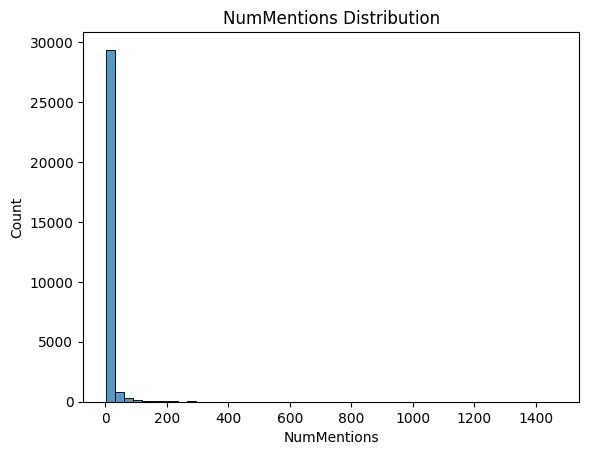

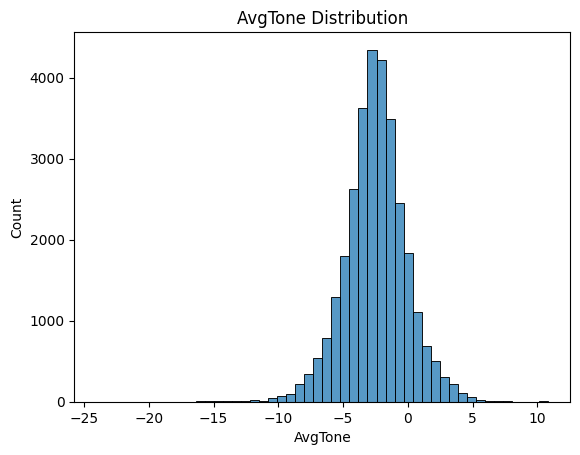

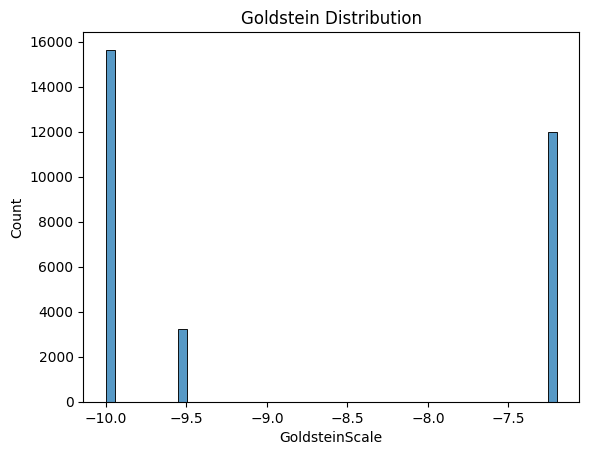

In [15]:
# 기사량 분포
sns.histplot(df['NumMentions'], bins=50)
plt.title("NumMentions Distribution")
plt.show()

# Tone 분포
sns.histplot(df['AvgTone'], bins=50)
plt.title("AvgTone Distribution")
plt.show()

# Goldstein 분포
sns.histplot(df['GoldsteinScale'], bins=50)
plt.title("Goldstein Distribution")
plt.show()

In [ ]:
## 좌표 -> 정상적인 범위.
print("Lat 범위:", df['ActionGeo_Lat'].min(), df['ActionGeo_Lat'].max())
print("Long 범위:", df['ActionGeo_Long'].min(), df['ActionGeo_Long'].max())

Lat 범위: -42.0 72.0
Long 범위: -157.972 178.417


## 필터링 조건 검증 EDA

In [17]:
## IsRootEvent 검증
## IsRootEnvet = 1 만 써도 될까..?

In [ ]:
# 비율 확인 => 비슷함
df['IsRootEvent'].value_counts(normalize=True)

IsRootEvent
1    0.5256
0    0.4744
Name: proportion, dtype: Float64

- IsRootEvent 비율: 거의 반반

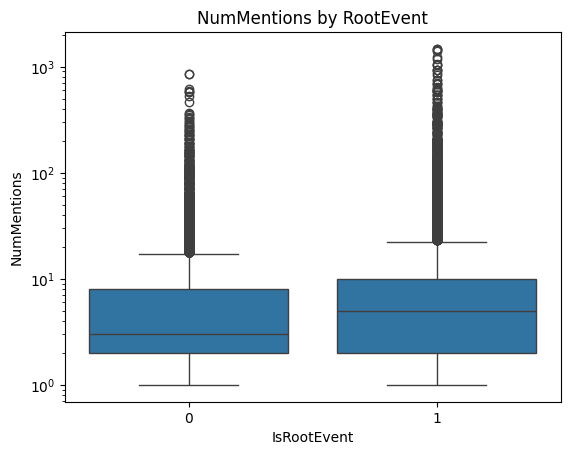

In [19]:
## 기사량 비교
sns.boxplot(x='IsRootEvent', y='NumMentions', data=df)
plt.yscale('log')
plt.title("NumMentions by RootEvent")
plt.show()

- root=1이 중앙값이 더 크다
- 상위 outlier 도 더 크다
- => root=1이 더 중요한 이벤트임을 확인함.

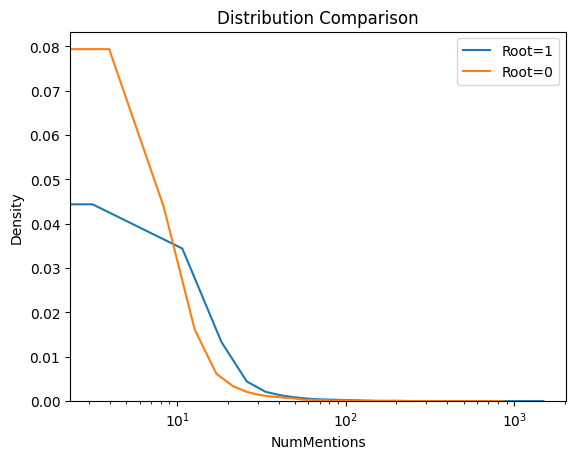

In [20]:
## 분포 비교
sns.kdeplot(df[df['IsRootEvent']==1]['NumMentions'], label='Root=1')
sns.kdeplot(df[df['IsRootEvent']==0]['NumMentions'], label='Root=0')
plt.xscale('log')
plt.legend()
plt.title("Distribution Comparison")
plt.show()

- root=0 : 작은값 (1~5)에 몰림 => 나중에 노이즈로서 작용할수도
- root=1 : 상대적으로 더 넓게 퍼져있음..

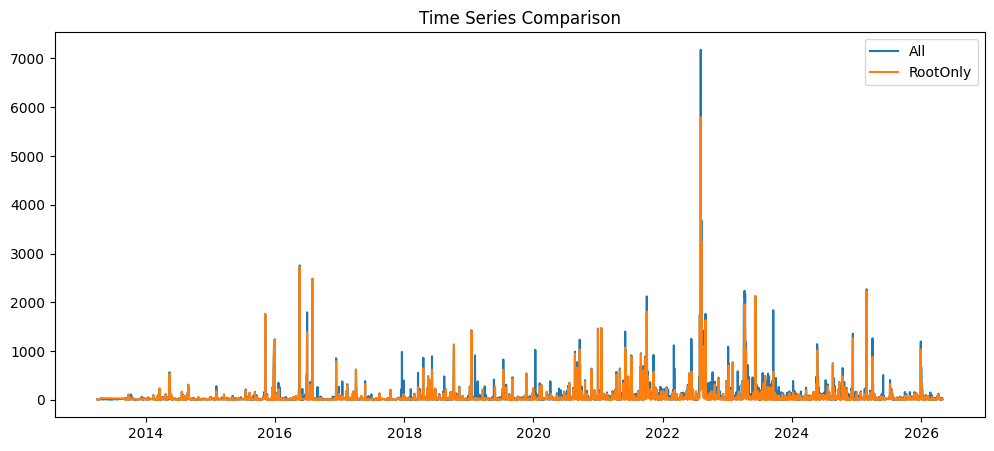

In [21]:
## 시간 흐름 비교
daily_all = df.groupby('SQLDATE')['NumMentions'].sum()
daily_root = df[df['IsRootEvent']==1].groupby('SQLDATE')['NumMentions'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_all, label='All')
plt.plot(daily_root, label='RootOnly')
plt.legend()
plt.title("Time Series Comparison")
plt.show()

- root=1만 써도 spike 구조 유지됨!!

In [22]:
## EventCode 분포 비교
pd.crosstab(df['EventCode'], df['IsRootEvent'], normalize='index')

IsRootEvent,0,1
EventCode,,
150,0.478155,0.521845
151,0.462833,0.537167
152,0.367521,0.632479
153,0.310345,0.689655
154,0.434112,0.565888
190,0.473512,0.526488
191,0.525745,0.474255
192,0.526648,0.473352
193,0.373368,0.626632


- 거의 모든 CAMEO 코드에서 비율이 비슷함
- root 필터가 특정 이벤트를 왜곡시키지 않음을 확인.
---
- 196 : 휴전 합의 위반 => 0
    - 메인 이벤트 발생 후, 설명느낌으로 다루기에, 메인사건으로 잘 안나옴.
- 203 : 인종 청소 => 1
    - 인종 청소, 이 자체가 headline. 너무 강한 이벤트라서 항상 메인 뉴스가 되는 것임.
- 이는 데이터 오류가 아니라, 이벤트 성격 차이.
- **-> IsRootEvent=1만 쓰는 전략은 더욱 정당화됨.**

In [23]:
## ActionGeo_Type 검증
## 어느 범위까지 쓸 것인가? -> 3, 4, 5
## 범위 1, 2는 제거해도 되는가?
## 실제로 위성 관측 가능한 수준인가?

In [24]:
## 분포 확인
df['ActionGeo_Type'].value_counts().sort_index()

ActionGeo_Type
0        4
1     7385
2      306
3      638
4    21824
5      722
Name: count, dtype: Int64

In [25]:
df['ActionGeo_Type'].value_counts(normalize=True).sort_index()

ActionGeo_Type
0     0.00013
1    0.239159
2     0.00991
3    0.020661
4    0.706759
5    0.023382
Name: proportion, dtype: Float64

- Type=4가 대부분
- 3, 5 도 의미 있는 수준으로 존재하긴 함.
- 2 : 너무 적음 -> 제거 가능

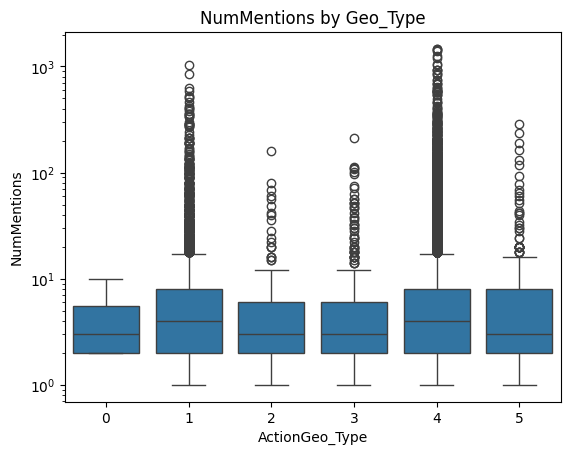

In [26]:
## type별 기사량 비교
sns.boxplot(x='ActionGeo_Type', y='NumMentions', data=df)
plt.yscale('log')
plt.title("NumMentions by Geo_Type")
plt.show()

- Type=4 : 압도적으로 큰 이벤트 포함
- Type=1 : 이벤트도 많지만, 위치가 문제임! (너무 큰 범위..)
- Type=3, 5 : 중간 정도..

In [43]:
## 핵심 지역 검증
keywords = ['Taiwan', 'Strait', 'Fujian', 'Taipei']

filtered = df[df['SOURCEURL'].str.contains('|'.join(keywords), case=False, na=False)]

filtered['ActionGeo_Type'].value_counts(normalize=True)

ActionGeo_Type
4    0.767808
1    0.183583
5     0.02354
3    0.018496
2    0.006522
0    0.000051
Name: proportion, dtype: Float64

- **Type=4 가 압도적임.**
- 실제 군사 hotspot => 거의 다 type=4임.

### IsRootEvent = 1 데이터에서 ActionGeo_Type 재검증

In [34]:
df_root = df[df['IsRootEvent'] == 1]

In [35]:
df_root.head()

,SQLDATE,IsRootEvent,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
1,2016-05-25,1,193,-10.0,7,-6.250000,4,22.512400,120.35900,http://www.chinapost.com.tw/taiwan/local/kaohs...
4,2016-05-25,1,154,-7.2,108,-4.085557,4,39.928900,116.38800,http://abcnews.go.com/International/wireStory/...
14,2017-02-05,1,190,-10.0,5,-6.535948,4,25.130300,121.50200,http://www.eyeontaiwan.com/father-kills-two-ch...
21,2016-12-26,1,192,-9.5,6,-2.197802,1,13.000000,122.00000,http://www.dailymail.co.uk/news/article-406614...
22,2016-12-26,1,190,-10.0,6,2.045455,4,0.333333,6.73333,http://www.dw.com/en/sao-tome-latest-target-in...


In [37]:
## ActionGeo_Type 분포 재확인
df_root['ActionGeo_Type'].value_counts()

ActionGeo_Type
4    11163
1     4171
3      403
5      330
2      159
0        4
Name: count, dtype: Int64

In [38]:
df_root['ActionGeo_Type'].value_counts(normalize=True)

ActionGeo_Type
4      0.6878
1    0.256993
3    0.024831
5    0.020333
2    0.009797
0    0.000246
Name: proportion, dtype: Float64

- 마찬가지로 Type=4 중심 구조

In [ ]:
## IsRootEvent=1 적용 전. 기사량 기준 ActionGeo_Type
threshold = df['NumMentions'].quantile(0.95)
df_high_2 = df[df['NumMentions'] >= threshold]

df_high_2['ActionGeo_Type'].value_counts(normalize=True)

ActionGeo_Type
4     0.78372
1    0.183007
3    0.015449
5    0.012478
2    0.005348
Name: proportion, dtype: Float64

In [39]:
## 기사량 기준 ActionGeo_Type
threshold = df_root['NumMentions'].quantile(0.95)
df_high = df_root[df_root['NumMentions'] >= threshold]

df_high['ActionGeo_Type'].value_counts(normalize=True)

ActionGeo_Type
4    0.762712
1      0.2046
5    0.014528
3    0.012107
2    0.006053
Name: proportion, dtype: Float64

- Type=4 비중 매우 큼

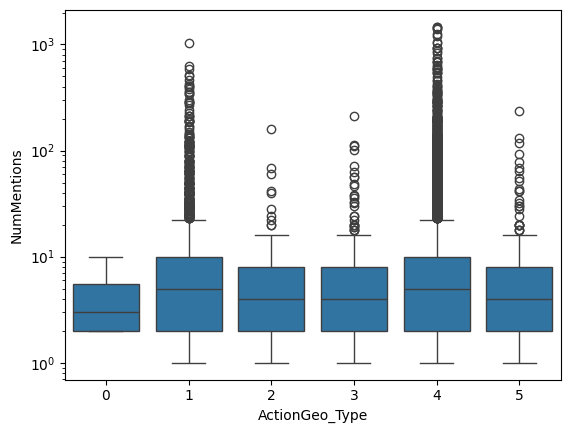

In [40]:
## ActionGeo_Type별 기사량 분포
sns.boxplot(x='ActionGeo_Type', y='NumMentions', data=df_root)
plt.yscale('log')
plt.show()

In [41]:
## 핵심 지역 재확인
filtered = df_root[df_root['SOURCEURL'].str.contains('Taiwan|Strait|Fujian|Taipei', case=False, na=False)]
filtered['ActionGeo_Type'].value_counts(normalize=True)

ActionGeo_Type
4    0.731705
1    0.213828
3    0.024159
5    0.022226
2    0.007994
0    0.000088
Name: proportion, dtype: Float64

- 군사적 중심지 등도 Type 4 중심

In [ ]:
## EventCode 검증
## 15, 19, 20 만 써도 핵심 군사 이벤트를 충분히 커버하는가??


In [45]:
## EventCode 전체 분포 확인
df_root['EventCode'].value_counts()

EventCode
190    5635
150    4061
154    1430
192    1350
193     960
194     914
151     766
195     710
191     175
152     148
202      55
153      20
201       3
203       3
Name: count, dtype: int64

- 데이터가 특정 코드에 몰려 있지만, 
- 한두 개... 코드로만 구성된 건 아니라.
- => 다양성 유지 O

In [46]:
## 중요 이벤트 기준 분포
threshold = df_root['NumMentions'].quantile(0.95)
df_high = df_root[df_root['NumMentions'] >= threshold]

df_high['EventCode'].value_counts(normalize=True)

EventCode
190    0.341404
150    0.295400
192    0.084746
194    0.075061
154    0.055690
151    0.049637
193    0.046005
195    0.030266
191    0.013317
152    0.008475
Name: proportion, dtype: float64

- 190, 150 에 몰려있지만, 적당히 분산되어 있음

In [47]:
## EventCode별 영향력 분석
df_root.groupby('EventCode')[['NumMentions','AvgTone']].mean().sort_values(by='NumMentions', ascending=False)

,NumMentions,AvgTone
EventCode,,
194,18.094092,-2.869722
192,14.214815,-2.456315
150,14.202413,-2.557962
190,12.417924,-2.539653
151,12.416449,-2.275097
193,11.109375,-2.879930
191,10.971429,-2.083404
195,9.625352,-2.707999
152,9.074324,-2.448471


In [50]:
df.groupby('EventCode')[['NumMentions','AvgTone']].mean().sort_values(by='NumMentions', ascending=False)

,NumMentions,AvgTone
EventCode,,
196,22.25,0.550388
194,13.416785,-2.697762
150,11.283346,-2.435073
151,11.146564,-2.340738
192,10.719144,-2.356242
190,9.920957,-2.536411
191,9.783198,-2.179997
152,9.478632,-2.534654
193,9.398172,-2.763412


In [49]:
## 중요 이벤트 유지 여부
target_codes = ['15','19','20']
df_reduced = df_root[df_root['EventCode'].str[:2].isin(target_codes)]

df_high_reduced = df_reduced[df_reduced['NumMentions'] >= threshold]
len(df_high_reduced) / len(df_high)

1.0

In [51]:
## 모든 필터링 조합 분석
## 필터링 조건을 통해, 의미 있는 데이터만 남기는가?

In [52]:
# 0. 원본 (이미 EventCode는 필터된 상태)
df_all = df.copy()

# 1. RootEvent
df_root = df_all[df_all['IsRootEvent'] == 1]

# 2. Geo_Type
df_geo = df_root[df_root['ActionGeo_Type'].isin([3,4,5])]

# 3. (EventCode는 이미 적용된 상태라 그대로)
df_final = df_geo.copy()

In [53]:
print("전체:", len(df_all))
print("Root:", len(df_root))
print("Geo:", len(df_geo))

전체: 30879
Root: 16230
Geo: 11896


In [54]:
print("Root 비율:", len(df_root)/len(df_all))
print("Geo 비율:", len(df_geo)/len(df_all))

Root 비율: 0.5255999222772758
Geo 비율: 0.3852456361928819


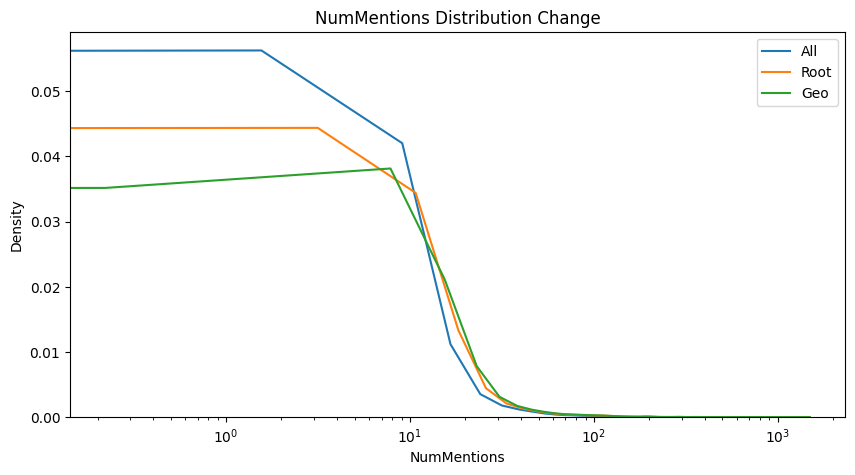

In [55]:
plt.figure(figsize=(10,5))

sns.kdeplot(df_all['NumMentions'], label='All')
sns.kdeplot(df_root['NumMentions'], label='Root')
sns.kdeplot(df_geo['NumMentions'], label='Geo')

plt.xscale('log')
plt.legend()
plt.title("NumMentions Distribution Change")
plt.show()

In [56]:
threshold = df_all['NumMentions'].quantile(0.95)

df_high_all = df_all[df_all['NumMentions'] >= threshold]
df_high_final = df_final[df_final['NumMentions'] >= threshold]

print("중요 이벤트 유지율:", len(df_high_final)/len(df_high_all))

중요 이벤트 유지율: 0.5264408793820559


C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


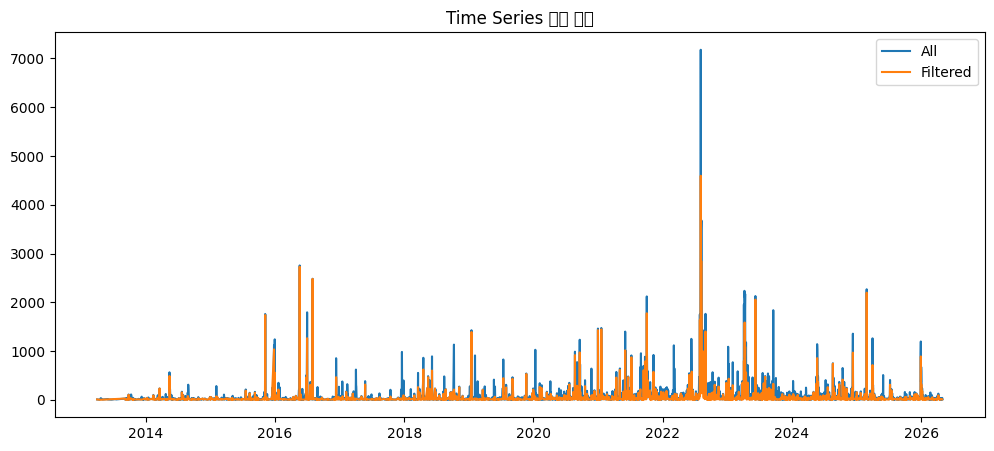

In [57]:
daily_all = df_all.groupby('SQLDATE')['NumMentions'].sum()
daily_final = df_final.groupby('SQLDATE')['NumMentions'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_all, label='All')
plt.plot(daily_final, label='Filtered')
plt.legend()
plt.title("Time Series 유지 여부")
plt.show()

In [58]:
print(df_all['ActionGeo_Type'].value_counts(normalize=True))
print(df_final['ActionGeo_Type'].value_counts(normalize=True))

ActionGeo_Type
4    0.706759
1    0.239159
5    0.023382
3    0.020661
2     0.00991
0     0.00013
Name: proportion, dtype: Float64
ActionGeo_Type
4    0.938383
3    0.033877
5     0.02774
Name: proportion, dtype: Float64
